<a href="https://colab.research.google.com/github/KuroNeko5536/JeongMan-v6-Robotic-Arm/blob/main/JeongMan6_linear_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import time
import joblib
import pandas as pd

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

class RobotIKDataset(Dataset):
    def __init__(self, X, y):
        X_numeric = X.astype(np.float32)
        y_numeric = y.astype(np.float32)

        self.X = torch.tensor(X_numeric, dtype=torch.float32)
        self.y = torch.tensor(y_numeric, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class IK_model(nn.Module):
    def __init__(self):
        super(IK_model, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 5)
        )

    def forward(self, x):
        return self.network(x)

class WeightedIKLoss(nn.Module):
  def __init__(self, device):
      super(WeightedIKLoss, self).__init__()
      self.weights = torch.tensor([15.0, 8.0, 7.5, 1.5, 1.0], dtype=torch.float32).to(device) # 링크 길이에 따라 차등적으로 loss 부여 ( 앞쪽 링크일수록 최종 값에 영향을 더 많이 주니까.. )

  def forward(self, pred, true):
      loss_per_element = (pred - true) ** 2

      weighted_loss = loss_per_element * self.weights

      return torch.mean(weighted_loss)

device: cuda


In [17]:
def train_pipeline():
    file_name = 'jeongman6_dataest.csv'

    print(f"loading {file_name}")
    start_time = time.time()

    df = pd.read_csv(file_name)
    print(f"shape: {df.shape}")

    nan_count = df.isnull().sum().sum()
    inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

    feature_cols = ['ee_x', 'ee_y', 'ee_z', 'ee_roll', 'ee_pitch', 'ee_yaw']
    target_cols = ['theta1', 'theta2', 'theta3', 'theta4', 'theta5']

    X_raw = df[feature_cols].values
    y_raw = df[target_cols].values

    del df

    print("preprocessing data . . .")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_raw, test_size=0.1, random_state=42)

    train_dataset = RobotIKDataset(X_train, y_train)
    val_dataset = RobotIKDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False)

    model = IK_model().to(device)
    criterion = WeightedIKLoss(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    epochs = 30
    print("training start . . .")

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        start_epoch = time.time()

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            #forward
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            #backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Time: {time.time()-start_epoch:.1f}s")

    torch.save(model.state_dict(), 'jeongman6_model.pth')
    joblib.dump(scaler, 'ik_scaler.pkl')
    print("train finished")

if __name__ == "__main__":
    train_pipeline()

loading robot_ik_dataset_v2.csv
shape: (5000000, 11)
preprocessing data...
training start . . .
Epoch [1/30] | Train Loss: 1.184304 | Val Loss: 0.728809 | Time: 42.7s
Epoch [2/30] | Train Loss: 0.593672 | Val Loss: 0.558683 | Time: 43.1s
Epoch [3/30] | Train Loss: 0.510310 | Val Loss: 0.361713 | Time: 42.5s
Epoch [4/30] | Train Loss: 0.465977 | Val Loss: 0.401418 | Time: 40.7s
Epoch [5/30] | Train Loss: 0.438025 | Val Loss: 0.294543 | Time: 42.8s
Epoch [6/30] | Train Loss: 0.411015 | Val Loss: 0.316413 | Time: 41.0s
Epoch [7/30] | Train Loss: 0.397235 | Val Loss: 0.275015 | Time: 42.2s
Epoch [8/30] | Train Loss: 0.379839 | Val Loss: 0.295055 | Time: 40.6s
Epoch [9/30] | Train Loss: 0.367844 | Val Loss: 0.248179 | Time: 43.4s
Epoch [10/30] | Train Loss: 0.349848 | Val Loss: 0.238590 | Time: 40.6s
Epoch [11/30] | Train Loss: 0.344393 | Val Loss: 0.245067 | Time: 42.2s
Epoch [12/30] | Train Loss: 0.333533 | Val Loss: 0.223814 | Time: 41.3s
Epoch [13/30] | Train Loss: 0.323373 | Val Loss: 

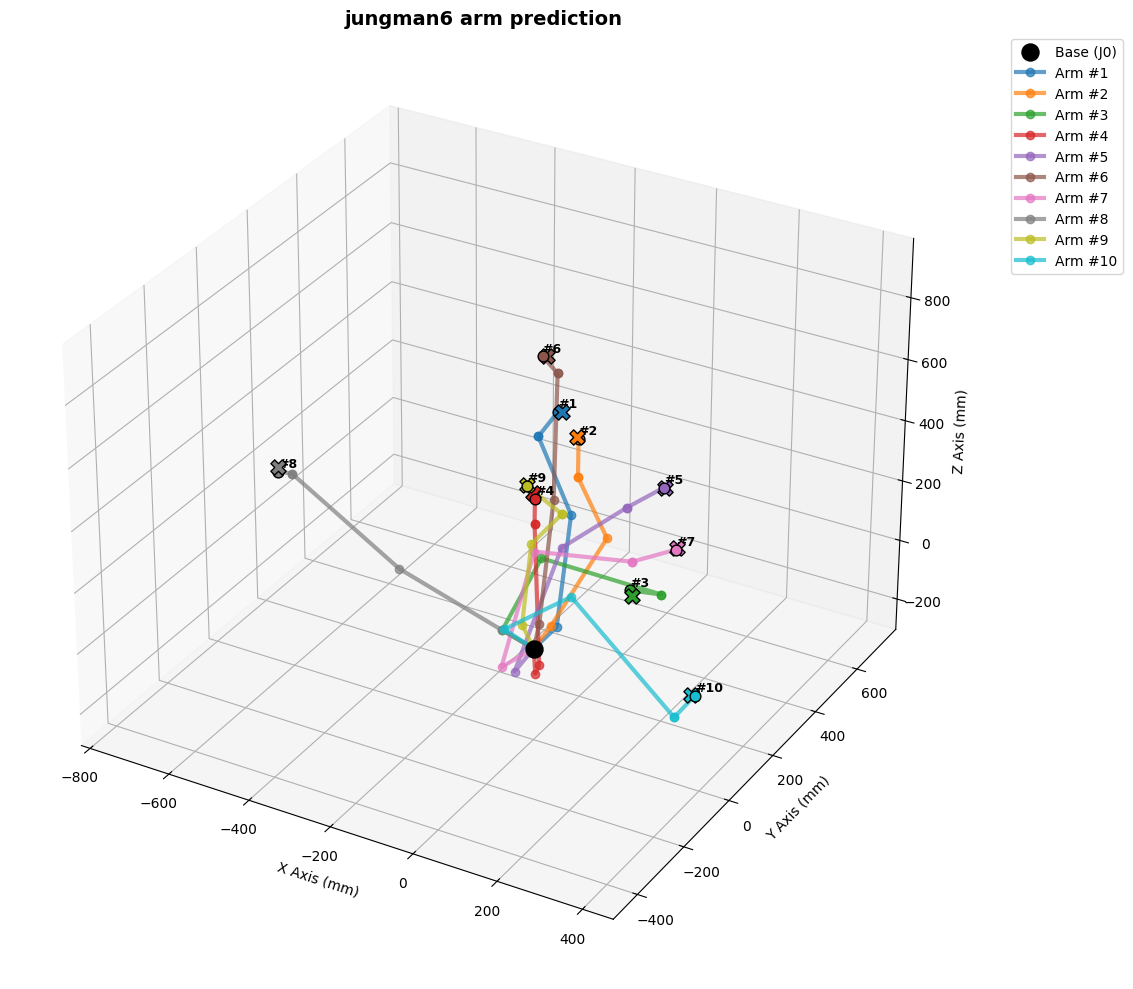

In [32]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def get_trans(theta, link_length):
    A0 = np.array([
        [np.cos(theta[0]), -np.sin(theta[0]), 0, 0],
        [np.sin(theta[0]),  np.cos(theta[0]), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    A1 = np.array([
        [np.cos(theta[1]), 0, -np.sin(theta[1]), link_length[0]],
        [0, 1, 0, 0],
        [np.sin(theta[1]), 0, np.cos(theta[1]), 0],
        [0, 0, 0, 1]
    ])

    theta2_prime = theta[2] + np.radians(71.9)

    A2 = np.array([
        [np.cos(theta2_prime), 0, -np.sin(theta2_prime), 0],
        [0, 1, 0, 0],
        [np.sin(theta2_prime), 0, np.cos(theta2_prime), link_length[1]],
        [0, 0, 0, 1]
    ])

    A3 = np.array([
        [1, 0, 0, link_length[2][0]],
        [0, np.cos(theta[3]), -np.sin(theta[3]), 0],
        [0, np.sin(theta[3]), np.cos(theta[3]), link_length[2][1]],
        [0, 0, 0, 1]
    ])

    A4 = np.array([
        [np.cos(theta[4]), 0, -np.sin(theta[4]), 0],
        [0, 1, 0, 0],
        [np.sin(theta[4]), 0, np.cos(theta[4]), 0],
        [0, 0, 0, 1]
    ])

    A5 = np.array([
        [1, 0, 0, link_length[3]],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

    A = [A0, A1, A2, A3, A4, A5]
    T = np.eye(4)
    joints = [[0, 0, 0]]

    for Ai in A:
        T = T @ Ai
        joints.append(T[:3, 3].copy())

    return np.array(joints)

def plot_multiple_robot_arms(all_joints, all_targets):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    colors = plt.cm.tab10(np.linspace(0, 1, len(all_joints)))
    ax.scatter(0, 0, 0, color='black', s=150, zorder=10, label='Base (J0)')

    total_x, total_y, total_z = [], [], []

    for idx, (joints, target_xyz) in enumerate(zip(all_joints, all_targets)):
        x, y, z = joints[:, 0], joints[:, 1], joints[:, 2]
        total_x.extend(x); total_y.extend(y); total_z.extend(z)

        ax.plot(x, y, z, '-o', color=colors[idx], linewidth=3, markersize=6, alpha=0.7,
                label=f'Arm #{idx+1}')
        ax.scatter(x[-1], y[-1], z[-1], color=colors[idx], s=60, edgecolors='black', zorder=5)

        ax.scatter(target_xyz[0], target_xyz[1], target_xyz[2],
                   color=colors[idx], marker='X', s=120, edgecolors='black', zorder=6)

        ax.text(x[-1], y[-1], z[-1] + 15.0, f"#{idx+1}", color='black', fontsize=9, fontweight='bold')

    ax.set_xlabel('X Axis (mm)')
    ax.set_ylabel('Y Axis (mm)')
    ax.set_zlabel('Z Axis (mm)')
    ax.set_title('jungman6 arm prediction', fontsize=14, fontweight='bold')

    total_x, total_y, total_z = np.array(total_x), np.array(total_y), np.array(total_z)
    max_range = np.array([total_x.max()-total_x.min(), total_y.max()-total_y.min(), total_z.max()-total_z.min()]).max() / 2.0
    mid_x = (total_x.max()+total_x.min())*0.5
    mid_y = (total_y.max()+total_y.min())*0.5
    mid_z = (total_z.max()+total_z.min())*0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.grid(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

def get_valid_random_target(link_lengths, min_dist=400.0, max_dist=900.0):
    max_rotation = [180, 50, 75, 90, 60]
    min_rotation = [-180, -90, -75, -90, -60]

    min_limits = np.radians(min_rotation)
    max_limits = np.radians(max_rotation)

    while True:
        rand_theta = [np.random.uniform(min_limits[i], max_limits[i]) for i in range(5)]
        joints = get_trans(rand_theta, link_lengths)
        ee_pure = joints[-1]

        distance = np.linalg.norm(ee_pure)

        if min_dist <= distance <= max_dist:
            A0 = np.array([[np.cos(rand_theta[0]), -np.sin(rand_theta[0]), 0, 0], [np.sin(rand_theta[0]), np.cos(rand_theta[0]), 0, 0], [0,0,1,0], [0,0,0,1]])
            A1 = np.array([[np.cos(rand_theta[1]), 0, -np.sin(rand_theta[1]), link_lengths[0]], [0,1,0,0], [np.sin(rand_theta[1]), 0, np.cos(rand_theta[1]), 0], [0,0,0,1]])
            A2 = np.array([[np.cos(rand_theta[2]+np.radians(71.9)), 0, -np.sin(rand_theta[2]+np.radians(71.9)), 0], [0,1,0,0], [np.sin(rand_theta[2]+np.radians(71.9)), 0, np.cos(rand_theta[2]+np.radians(71.9)), link_lengths[1]], [0,0,0,1]])
            A3 = np.array([[1,0,0,link_lengths[2][0]], [0,np.cos(rand_theta[3]),-np.sin(rand_theta[3]),0], [0,np.sin(rand_theta[3]),np.cos(rand_theta[3]),link_lengths[2][1]], [0,0,0,1]])
            A4 = np.array([[np.cos(rand_theta[4]), 0, -np.sin(rand_theta[4]), 0], [0,1,0,0], [np.sin(rand_theta[4]), 0, np.cos(rand_theta[4]), 0], [0,0,0,1]])
            A5 = np.array([[1,0,0,link_lengths[3]], [0,1,0,0], [0,0,1,0], [0,0,0,1]])
            T = A0 @ A1 @ A2 @ A3 @ A4 @ A5

            r11, r21, r31 = T[0, 0], T[1, 0], T[2, 0]
            r32, r33 = T[2, 1], T[2, 2]

            yaw = np.arctan2(r21, r11)
            pitch = np.arctan2(-r31, np.sqrt(r32**2 + r33**2))
            roll = np.arctan2(r32, r33)

            target_pos = [ee_pure[0], ee_pure[1], ee_pure[2], roll, pitch, yaw]
            return target_pos

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    try:
        scaler = joblib.load('ik_scaler.pkl')
        model = IK_model().to(device)
        model.load_state_dict(torch.load('jeongman6_model.pth', map_location=device))
        model.eval()
    except FileNotFoundError as e:
        print(f"fucking file err: {e}")
        return

    link_lengths = [100, 333, [117, 358], 100]

    target_list = []
    predicted_joints_list = []

    for i in range(10):
        target_position = get_valid_random_target(link_lengths, min_dist=400.0, max_dist=900.0)
        target_list.append(target_position)

        target_array = np.array([target_position])
        scaled_input = scaler.transform(target_array)

        input_tensor = torch.tensor(scaled_input, dtype=torch.float32).to(device)
        with torch.no_grad():
            predicted_theta_tensor = model(input_tensor)

            predicted_theta = predicted_theta_tensor.cpu().numpy().flatten()

        joint_positions = get_trans(predicted_theta, link_lengths)
        predicted_joints_list.append(joint_positions)

    plot_multiple_robot_arms(predicted_joints_list, [t[:3] for t in target_list])

if __name__ == "__main__":
    main()